---
## Part 1: Setup and Imports

First, let's import all the necessary libraries.

In [1]:
# Standard imports
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Check Python version
print(f"Python version: {sys.version}")
assert sys.version_info >= (3, 7), "Python 3.7 or above is required"

# Scikit-learn imports
import sklearn
print(f"Scikit-learn version: {sklearn.__version__}")

# Set plot defaults
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

Python version: 3.10.19 | packaged by conda-forge | (main, Jan 26 2026, 23:39:36) [MSC v.1944 64 bit (AMD64)]
Scikit-learn version: 1.7.2


---
## Part 2: Load and Explore the Data

### 2.1 Load the Dataset

📝 **Your Task:** Load the CSV file containing the transcription data.

💡 **Hint:** Use `pd.read_csv()` to load the data from `Data_AUG_13.11.2024_output.csv`

In [2]:
# TODO: Load the dataset
# data = pd.read_csv(___)

# Your code here:
data = pd.read_csv('Data_AUG_13.11.2024_output.csv')

### 2.2 Take a Quick Look at the Data Structure

📝 **Your Task:** Explore the basic structure of the data:
1. Display the first few rows
2. Check the data types and non-null counts
3. Get statistical summary

💡 **Hint:** Use `.head()`, `.info()`, and `.describe()` methods

In [3]:
# TODO: Display the first 5 rows
# Your code here:
data.head()


,Record-ID,TrainOrDev,Class,Gender,Age,Converted-MMSE,Transcript_PFT,Transcript_CTD,Transcript_SFT,Class_label,...,filler_count,token_count,type_count,type_token_ratio,ma_ttr,brunets_index,content_density,repetitions,sentence_count,average_words_per_sentence
0,Process-rec-001,train,MCI,1,62,25.0,"Pat: People, partner, plate, platter, pants, p...",NaN,"Pat: (3 seconds) Giraffe, kangaroo, lion, tige...",1,...,1,0,0,0.000000,0.000000,0.000000,0.000000,{},0,0.000000
1,Process-rec-002,dev,MCI,1,61,25.0,"Pat: (1 second) Pipe, plane, people (5 seconds...",Pat: (4 seconds) There’s a lad stood on the st...,"Pat: (1 second) Dogs, cats, birds (1 second) m...",1,...,2,76,46,0.605263,1.000000,1.487174,0.421053,"{'there': 2, 's': 7, 'a': 5, 'stood': 2, 'on':...",5,15.200000
2,Process-rec-003,train,MCI,0,62,29.0,"Pat: Um (1 second) purple, pale, placid (1 sec...","Pat: (3 seconds) Um, the picture is of a kitch...","Pat: Cow, bull, ewe, ram, chicken, goose, um (...",1,...,6,150,84,0.560000,0.995495,1.620714,0.433333,"{'the': 10, 'is': 5, 'of': 2, 'a': 10, 'there'...",7,21.428571
3,Process-rec-004,dev,MCI,0,67,29.0,Pat: Plank (1 second) pool (1 second) swimming...,"Pat: A mother presumably, or a fe, an adult fe...",Pat: Um (1 second) impala (1 second) er cheeta...,1,...,4,162,88,0.543210,1.000000,1.675909,0.425926,"{'a': 5, 'or': 2, 'an': 4, 'adult': 3, 'female...",4,40.500000
4,Process-rec-005,train,MCI,1,65,27.0,"Pat: It’s er pillock, er post box, er Pyracant...",Pat: ‘50s style er scene of domestic um confus...,"Pat: Dog, cat, giraffe, wallaby, kangaroo, tor...",1,...,4,44,36,0.818182,1.000000,1.057222,0.500000,"{'s': 3, 'of': 4, 'the': 3, 'and': 2}",1,44.000000


In [4]:
# TODO: Check data types and missing values
# Your code here:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Record-ID                   157 non-null    object 
 1   TrainOrDev                  157 non-null    object 
 2   Class                       157 non-null    object 
 3   Gender                      157 non-null    int64  
 4   Age                         157 non-null    object 
 5   Converted-MMSE              157 non-null    float64
 6   Transcript_PFT              157 non-null    object 
 7   Transcript_CTD              156 non-null    object 
 8   Transcript_SFT              157 non-null    object 
 9   Class_label                 157 non-null    int64  
 10  total_seconds               157 non-null    int64  
 11  Parentheses_Content         157 non-null    object 
 12  CTD_Cleaned                 156 non-null    object 
 13  found_fillers               157 non

In [5]:
# TODO: Get statistical summary of numerical columns
# Your code here:
data.describe()

,Gender,Converted-MMSE,Class_label,total_seconds,filler_count,token_count,type_count,type_token_ratio,ma_ttr,brunets_index,content_density,sentence_count,average_words_per_sentence
count,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000
mean,0.490446,27.362319,0.579618,8.707006,8.439490,160.968153,81.146497,0.549390,0.984488,1.696550,0.417023,8.146497,21.729531
std,0.514132,1.628949,0.671082,9.365280,7.901101,93.990822,34.688876,0.114339,0.079816,0.374565,0.046259,5.168712,9.591882
min,0.000000,19.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,27.362319,0.000000,2.000000,3.000000,92.000000,54.000000,0.480392,0.986979,1.487174,0.398810,5.000000,16.600000
50%,0.000000,27.362319,0.000000,6.000000,6.000000,140.000000,76.000000,0.548193,0.992593,1.656918,0.414773,7.000000,20.142857
75%,1.000000,28.000000,1.000000,13.000000,12.000000,207.000000,101.000000,0.602273,0.997636,1.909074,0.435897,10.000000,24.400000
max,2.000000,30.000000,2.000000,62.000000,40.000000,485.000000,191.000000,1.000000,1.000000,2.716818,0.576923,26.000000,74.500000


### 2.3 Understand the Target Variable

📝 **Your Task:** Explore the target variable `Class_label`:
1. Check the unique values
2. Check the class distribution (value counts)
3. Visualize the class distribution

💡 **Hint:** Use `.value_counts()` and `.plot.bar()`

🤔 **Think About:** Is this a balanced or imbalanced dataset? How might this affect your model?

In [6]:
# TODO: Check the distribution of the target variable (Class_label)
# Your code here:
target_var = data.Class_label
target_var.value_counts()

Class_label
0    82
1    59
2    16
Name: count, dtype: int64

<Axes: >

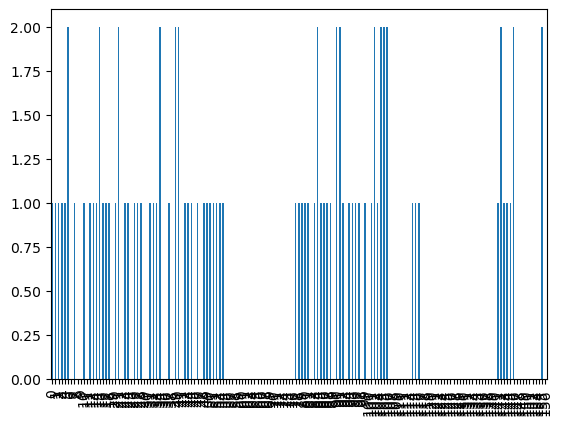

In [7]:
# TODO: Visualize the class distribution with a bar plot
# Your code here:
target_var.plot.bar()

### 2.4 Explore the Features

📝 **Your Task:** Identify which columns are:
- **Numerical features** (can be used directly)
- **Categorical features** (may need encoding)
- **Text columns** (transcriptions - may need special processing)
- **ID/metadata columns** (should be excluded from training)

💡 **Hint:** Look at columns like `token_count`, `type_token_ratio`, `filler_count`, etc.

In [8]:
# TODO: List all column names
# Your code here:
data.columns

Index(['Record-ID', 'TrainOrDev', 'Class', 'Gender', 'Age', 'Converted-MMSE',
       'Transcript_PFT', 'Transcript_CTD', 'Transcript_SFT', 'Class_label',
       'total_seconds', 'Parentheses_Content', 'CTD_Cleaned', 'found_fillers',
       'filler_list', 'filler_count', 'token_count', 'type_count',
       'type_token_ratio', 'ma_ttr', 'brunets_index', 'content_density',
       'repetitions', 'sentence_count', 'average_words_per_sentence'],
      dtype='object')

In [9]:
# TODO: Identify numerical columns that could be good features
# Hint: Columns like 'filler_count', 'token_count', 'type_count', 
# 'type_token_ratio', 'content_density', 'sentence_count', etc.

# Your code here:
numerical_columns = data.select_dtypes(include='number').columns
numerical_columns

Index(['Gender', 'Converted-MMSE', 'Class_label', 'total_seconds',
       'filler_count', 'token_count', 'type_count', 'type_token_ratio',
       'ma_ttr', 'brunets_index', 'content_density', 'sentence_count',
       'average_words_per_sentence'],
      dtype='object')

### 2.5 Visualize Feature Distributions

📝 **Your Task:** Create histograms for the numerical features.

💡 **Hint:** Use `df[numerical_columns].hist()` like we did in Chapter 2

array([[<Axes: title={'center': 'Gender'}>,
        <Axes: title={'center': 'Converted-MMSE'}>,
        <Axes: title={'center': 'Class_label'}>,
        <Axes: title={'center': 'total_seconds'}>],
       [<Axes: title={'center': 'filler_count'}>,
        <Axes: title={'center': 'token_count'}>,
        <Axes: title={'center': 'type_count'}>,
        <Axes: title={'center': 'type_token_ratio'}>],
       [<Axes: title={'center': 'ma_ttr'}>,
        <Axes: title={'center': 'brunets_index'}>,
        <Axes: title={'center': 'content_density'}>,
        <Axes: title={'center': 'sentence_count'}>],
       [<Axes: title={'center': 'average_words_per_sentence'}>, <Axes: >,
        <Axes: >, <Axes: >]], dtype=object)

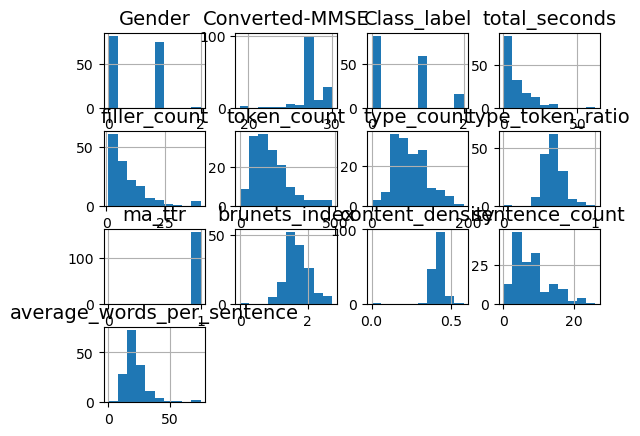

In [10]:
# TODO: Create histograms for numerical features
# Your code here:
data[numerical_columns].hist()

---
## Part 3: Data Preparation

### 3.1 Select Features for Classification

📝 **Your Task:** Select the features you want to use for classification.

Consider using these numerical features:
- `filler_count` - Number of filler words (um, uh, etc.)
- `token_count` - Total number of words
- `type_count` - Number of unique words
- `type_token_ratio` - Vocabulary diversity measure
- `content_density` - Content word ratio
- `sentence_count` - Number of sentences
- `average_words_per_sentence` - Sentence complexity
- `Age` - Patient age
- `Converted-MMSE` - Cognitive assessment score

💡 **Hint:** Create a list of feature column names and extract them into X

In [11]:
# TODO: Define your feature columns
# feature_columns = [___]

# Your code here:
feature_columns = [
    'filler_count',
    'token_count',
    'type_count',
    'type_token_ratio',
    'content_density',
    'sentence_count',
    'average_words_per_sentence',
    'Age',
    'Converted-MMSE']

In [12]:
# TODO: Create X (features) and y (target)
# X = data[feature_columns]
# y = data['Class_label']

# Your code here:
X = data[feature_columns]
y = data['Class_label']


In [13]:
# TODO: Check the shapes of X and y
# Your code here:
print("X shape:", X.shape)
print("y shape:", y.shape) 

X shape: (157, 9)
y shape: (157,)


### 3.2 Handle Missing Values

📝 **Your Task:** Check for and handle missing values in your features.

💡 **Hint:** Use `.isnull().sum()` to check, and consider using `.fillna()` or `SimpleImputer` from sklearn

In [14]:
# TODO: Check for missing values in X
# Your code here:
X.isnull().sum()

filler_count                  0
token_count                   0
type_count                    0
type_token_ratio              0
content_density               0
sentence_count                0
average_words_per_sentence    0
Age                           0
Converted-MMSE                0
dtype: int64

In [ ]:
# TODO: Handle missing values if any exist
# Option 1: Fill with median

# Option 2: Use SimpleImputer


# Your code here:
X = X.apply(pd.to_numeric, errors='coerce')
if X.isnull().any().any():
    from sklearn.impute import SimpleImputer
    imputer = SimpleImputer(strategy='median')
    X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)
    print("Imputed missing values with column medians.")
else:
    print("No missing values in X, nothing to impute.")

Imputed missing values with column medians.


### 3.3 Create Train/Test Split

📝 **Your Task:** Split the data into training and test sets.

⚠️ **Important:** Use **stratified sampling** to maintain class proportions!

💡 **Hint:** Use `train_test_split()` with `stratify=y` parameter (like in Chapter 2)

In [18]:
from sklearn.model_selection import train_test_split

# TODO: Split the data with stratification


# Your code here:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,       # 20% test set, adjust if needed
    random_state=89,     # for reproducibility
    stratify=y           # preserve class distribution [web:40][web:46]
)

In [19]:
# TODO: Verify the split - check shapes and class distribution in both sets
# Your code here:
print("y distribution overall:\n", y.value_counts(normalize=True))
print("y_train distribution:\n", y_train.value_counts(normalize=True))
print("y_test distribution:\n", y_test.value_counts(normalize=True))


y distribution overall:
 Class_label
0    0.522293
1    0.375796
2    0.101911
Name: proportion, dtype: float64
y_train distribution:
 Class_label
0    0.520
1    0.376
2    0.104
Name: proportion, dtype: float64
y_test distribution:
 Class_label
0    0.53125
1    0.37500
2    0.09375
Name: proportion, dtype: float64


### 3.4 Feature Scaling

📝 **Your Task:** Scale the features using StandardScaler.

⚠️ **Important:** 
- Fit the scaler on training data only!
- Transform both training and test data with the same scaler

💡 **Hint:** Use `StandardScaler` from sklearn.preprocessing

In [20]:
from sklearn.preprocessing import StandardScaler

# TODO: Create scaler, fit on training data, transform both sets
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# Your code here:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) 

---
## Part 4: Training Binary Classifiers

Now let's train some classifiers! Remember from Chapter 3, we can use various algorithms.

### 4.1 Train an SGDClassifier

📝 **Your Task:** Train an SGDClassifier on the training data.

💡 **Hint:** Like in Chapter 3, use `SGDClassifier(random_state=42)`

In [21]:
from sklearn.linear_model import SGDClassifier

# TODO: Create and train the SGDClassifier


# Your code here:
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train_scaled, y_train)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


In [22]:
# TODO: Make predictions on a few samples from the test set
# Your code here:
y_test_pred_sgd = sgd_clf.predict(X_test_scaled)

### 4.2 Train a Random Forest Classifier

📝 **Your Task:** Train a RandomForestClassifier.

💡 **Hint:** Random Forests often perform well and can work without scaling

In [23]:
from sklearn.ensemble import RandomForestClassifier

# TODO: Create and train the RandomForestClassifier
# Note: RF doesn't need scaled features

# Your code here:
rf_clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_clf.fit(X_train, y_train) 

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### 4.3 (Optional) Try Other Classifiers

📝 **Your Task:** Try at least one more classifier.

Options to try:
- `LogisticRegression`
- `SVC` (Support Vector Classifier)
- `KNeighborsClassifier`
- you can be creative and try others too! or maybe somthing from hugging face like bert or distilbert for text classification

In [ ]:
# TODO: Try another classifier of your choice
# from sklearn.linear_model import LogisticRegression
# log_clf = LogisticRegression(random_state=42, max_iter=1000)
# log_clf.fit(X_train_scaled, y_train)

# Your code here:

---
## Part 5: Performance Evaluation

### 5.1 Cross-Validation Accuracy

📝 **Your Task:** Evaluate your classifiers using cross-validation.

💡 **Hint:** Use `cross_val_score()` with `cv=5` (5-fold cross-validation)

In [25]:
from sklearn.model_selection import cross_val_score

# TODO: Evaluate SGDClassifier with cross-validation
# scores = cross_val_score(sgd_clf, X_train_scaled, y_train, cv=5, scoring='accuracy')
# print(f"SGD Accuracy: {scores.mean():.3f} (+/- {scores.std():.3f})")

# Your code here:
scores = cross_val_score(
    sgd_clf,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='accuracy'
)

print(f"SGD Accuracy: {scores.mean():.3f} (+/- {scores.std():.3f})")



SGD Accuracy: 0.496 (+/- 0.090)


In [26]:
# TODO: Evaluate RandomForestClassifier with cross-validation
# Your code here:
scores_rf = cross_val_score(
    rf_clf,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print(f"RF Accuracy: {scores_rf.mean():.3f} (+/- {scores_rf.std():.3f})")

RF Accuracy: 0.552 (+/- 0.047)


### 5.2 Confusion Matrix

📝 **Your Task:** Generate and visualize the confusion matrix.

💡 **Hint:** Use `cross_val_predict()` to get predictions, then `confusion_matrix()` or `ConfusionMatrixDisplay`

🤔 **Think About:** What do the different quadrants mean?
- True Positives (TP): Correctly predicted positive class
- True Negatives (TN): Correctly predicted negative class
- False Positives (FP): Incorrectly predicted as positive
- False Negatives (FN): Incorrectly predicted as negative

In [29]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# TODO: Get predictions using cross-validation
# y_train_pred = cross_val_predict(sgd_clf, X_train_scaled, y_train, cv=5)

# Your code here:
y_train_pred = cross_val_predict(
    sgd_clf,
    X_train_scaled,
    y_train,
    cv=5
)

In [28]:
# TODO: Display the confusion matrix
# Option 1: Simple matrix
# cm = confusion_matrix(y_train, y_train_pred)
# print(cm)

# Option 2: Visual display
# ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred)
# plt.show()

# Your code here:
cm = confusion_matrix(y_train, y_train_pred)
print(cm)

[[34 21 10]
 [18 26  3]
 [ 4  7  2]]


### 5.3 Precision, Recall, and F1-Score

📝 **Your Task:** Calculate precision, recall, and F1-score for your classifiers.

💡 **Hint:** Use `precision_score()`, `recall_score()`, and `f1_score()` from sklearn.metrics

🤔 **Think About:**
- **Precision** = TP / (TP + FP) - When we predict positive, how often are we correct?
- **Recall** = TP / (TP + FN) - Of all actual positives, how many did we catch?
- **F1** = Harmonic mean of precision and recall

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# TODO: Calculate and print precision, recall, and F1 score


# Your code here:

from sklearn.metrics import precision_score, recall_score, f1_score

precision_per_class = precision_score(y_train, y_train_pred, average=None)
recall_per_class    = recall_score(y_train, y_train_pred, average=None)
f1_per_class        = f1_score(y_train, y_train_pred, average=None)

print("Precision per class:", precision_per_class)
print("Recall per class:   ", recall_per_class)
print("F1 per class:       ", f1_per_class)


Precision per class: [0.60714286 0.48148148 0.13333333]
Recall per class:    [0.52307692 0.55319149 0.15384615]
F1 per class:        [0.56198347 0.51485149 0.14285714]


### 5.4 Precision-Recall Curve

📝 **Your Task:** Plot the precision-recall curve.

💡 **Hint:** 
1. Get decision scores using `cross_val_predict()` with `method='decision_function'` or `method='predict_proba'`
2. Use `precision_recall_curve()` to compute the curve
3. Plot precisions vs recalls

In [35]:
from sklearn.metrics import precision_recall_curve

# TODO: Get decision scores (for classifiers that support it)
# For SGDClassifier:


# Your code here:
y_train_pos = (y_train == 1).astype(int)
y_scores = cross_val_predict(
    sgd_clf,
    X_train_scaled,
    y_train_pos,
    cv=5,
    method="decision_function"
)

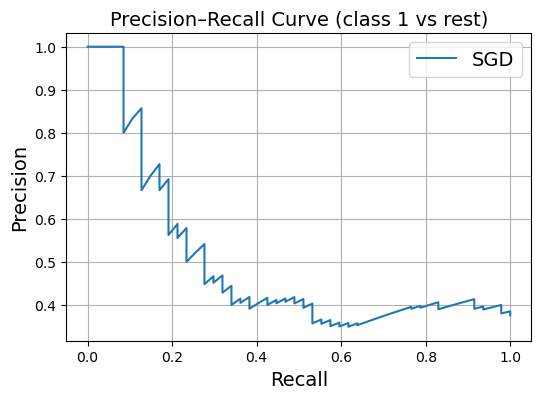

In [36]:
# TODO: Compute and plot the precision-recall curve


# Your code here:
precisions, recalls, thresholds = precision_recall_curve(y_train_pos, y_scores)  # [web:144][web:150]

# 4) Plot curve
plt.figure(figsize=(6, 4))
plt.plot(recalls, precisions, label="SGD")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (class 1 vs rest)")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# TODO: Display the first 5 rows
# Your code here:
data.head()


,Record-ID,TrainOrDev,Class,Gender,Age,Converted-MMSE,Transcript_PFT,Transcript_CTD,Transcript_SFT,Class_label,...,filler_count,token_count,type_count,type_token_ratio,ma_ttr,brunets_index,content_density,repetitions,sentence_count,average_words_per_sentence
0,Process-rec-001,train,MCI,1,62,25.0,"Pat: People, partner, plate, platter, pants, p...",NaN,"Pat: (3 seconds) Giraffe, kangaroo, lion, tige...",1,...,1,0,0,0.000000,0.000000,0.000000,0.000000,{},0,0.000000
1,Process-rec-002,dev,MCI,1,61,25.0,"Pat: (1 second) Pipe, plane, people (5 seconds...",Pat: (4 seconds) There’s a lad stood on the st...,"Pat: (1 second) Dogs, cats, birds (1 second) m...",1,...,2,76,46,0.605263,1.000000,1.487174,0.421053,"{'there': 2, 's': 7, 'a': 5, 'stood': 2, 'on':...",5,15.200000
2,Process-rec-003,train,MCI,0,62,29.0,"Pat: Um (1 second) purple, pale, placid (1 sec...","Pat: (3 seconds) Um, the picture is of a kitch...","Pat: Cow, bull, ewe, ram, chicken, goose, um (...",1,...,6,150,84,0.560000,0.995495,1.620714,0.433333,"{'the': 10, 'is': 5, 'of': 2, 'a': 10, 'there'...",7,21.428571
3,Process-rec-004,dev,MCI,0,67,29.0,Pat: Plank (1 second) pool (1 second) swimming...,"Pat: A mother presumably, or a fe, an adult fe...",Pat: Um (1 second) impala (1 second) er cheeta...,1,...,4,162,88,0.543210,1.000000,1.675909,0.425926,"{'a': 5, 'or': 2, 'an': 4, 'adult': 3, 'female...",4,40.500000
4,Process-rec-005,train,MCI,1,65,27.0,"Pat: It’s er pillock, er post box, er Pyracant...",Pat: ‘50s style er scene of domestic um confus...,"Pat: Dog, cat, giraffe, wallaby, kangaroo, tor...",1,...,4,44,36,0.818182,1.000000,1.057222,0.500000,"{'s': 3, 'of': 4, 'the': 3, 'and': 2}",1,44.000000


### 5.5 ROC Curve and AUC

📝 **Your Task:** Plot the ROC curve and calculate the AUC score.

💡 **Hint:** Use `roc_curve()` and `roc_auc_score()` from sklearn.metrics

🤔 **Think About:** 
- ROC shows True Positive Rate vs False Positive Rate
- AUC of 0.5 = random classifier, AUC of 1.0 = perfect classifier

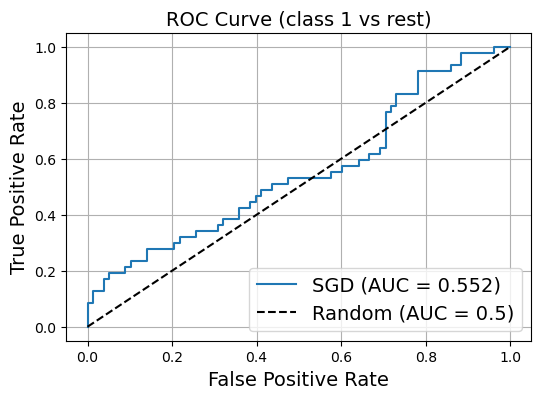

In [40]:
from sklearn.metrics import roc_curve, roc_auc_score

# TODO: Compute and plot the ROC curve


# Your code here:
fpr, tpr, thresholds = roc_curve(y_train_pos, y_scores)

roc_auc = roc_auc_score(y_train_pos, y_scores) 

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"SGD (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.5)")  # baseline [web:156][web:163]
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (class 1 vs rest)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [41]:
# TODO: Calculate the AUC score


# Your code here:
roc_auc = roc_auc_score(y_train_pos, y_scores)
print(f"SGD ROC AUC: {roc_auc:.3f}")

SGD ROC AUC: 0.552


---
## Part 6: Final Evaluation on Test Set

📝 **Your Task:** Choose your best model and evaluate it on the **held-out test set**.

⚠️ **Important:** Only do this ONCE at the very end! The test set should remain untouched until final evaluation.

💡 **Hint:** Use the same metrics you used before on the test set predictions

In [43]:
# TODO: Make predictions on the test set with your best model
# y_test_pred = best_clf.predict(X_test_scaled)  # or X_test for RF

# Your code here:
y_test_pred = rf_clf.predict(X_test)


In [44]:
# TODO: Calculate all metrics on the test set
# - Accuracy
# - Precision
# - Recall
# - F1 Score
# - AUC Score

from sklearn.metrics import accuracy_score, classification_report

# Your code here:
test_acc  = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred, average='weighted')
test_rec  = recall_score(y_test, y_test_pred, average='weighted')
test_f1   = f1_score(y_test, y_test_pred, average='weighted')

print(f"Accuracy:  {test_acc:.3f}")
print(f"Precision: {test_prec:.3f}")
print(f"Recall:    {test_rec:.3f}")
print(f"F1-score:  {test_f1:.3f}")

Accuracy:  0.688
Precision: 0.706
Recall:    0.688
F1-score:  0.670


In [ ]:
# TODO: Print a complete classification report


# Your code here:
from sklearn.metrics import classification_report
print("Classification report on test set:")
print(classification_report(y_test, y_test_pred))


Classification report on test set:
              precision    recall  f1-score   support

           0       0.68      0.88      0.77        17
           1       0.67      0.50      0.57        12
           2       1.00      0.33      0.50         3

    accuracy                           0.69        32
   macro avg       0.78      0.57      0.61        32
weighted avg       0.71      0.69      0.67        32



---
## Part 7: Error Analysis (Optional but Recommended)

📝 **Your Task:** Analyze the errors your model makes.

🤔 **Think About:**
- Which samples are being misclassified?
- Is there a pattern in the errors?
- Which features might need more engineering?

In [ ]:
# TODO: Analyze misclassified samples
# Hint: Find samples where y_train != y_train_pred and examine their features

# Your code here:

---
## Part 8: Feature Importance (Optional)

📝 **Your Task:** If using Random Forest, examine feature importances.

💡 **Hint:** Use `forest_clf.feature_importances_` to see which features matter most

In [ ]:
# TODO: Plot feature importances from Random Forest
# importances = forest_clf.feature_importances_
# indices = np.argsort(importances)[::-1]
# 
# plt.figure(figsize=(10, 6))
# plt.title("Feature Importances")
# plt.bar(range(len(importances)), importances[indices])
# plt.xticks(range(len(importances)), [feature_columns[i] for i in indices], rotation=45)
# plt.tight_layout()
# plt.show()

# Your code here:

---
## Summary and Conclusions

📝 **Your Task:** Write a brief summary of your findings:

1. **Best Model:** Which classifier performed best?
2. **Key Metrics:** What were the final precision, recall, and F1 scores?
3. **Important Features:** Which features were most important for classification?
4. **Challenges:** What challenges did you encounter?
5. **Future Improvements:** What could be done to improve the model?

### Your Summary:

1. **Best Model:** Random Forest (RF) performed best. It was chosen over SGDClassifier: cross-validation gave RF ~55% accuracy vs SGD ~50%. Final evaluation was done with `rf_clf` on the held-out test set.

2. **Key Metrics:** On the test set: **Accuracy 0.688**, **Precision 0.706** (weighted), **Recall 0.688**, **F1-score 0.670**. The classification report showed stronger performance on class 0 (recall 0.88) and weaker on the minority class 2 (recall 0.33, only 3 test samples).

3. **Important Features:** Features used were linguistic/demographic: filler_count, token_count, type_count, type_token_ratio, content_density, sentence_count, average_words_per_sentence, Age, and Converted-MMSE. For Random Forest, the most informative are typically lexical/diversity and cognitive (e.g. MMSE, type-token ratio); plotting `rf_clf.feature_importances_` would show the exact ranking.

4. **Challenges:** Non-numeric values in the data (e.g. "66*") required converting to numeric with `pd.to_numeric(..., errors='coerce')` before imputation. Small sample size (157 rows, 32 test) and class imbalance (especially class 2) limited stability and recall for minority classes.

5. **Future Improvements:** There are a couple things I should consider for improvement in the future: 1. Use more data and consider resampling/class weights for imbalance. 2. Add text-based features from the transcripts (e.g. embeddings or TF-IDF). 3. Hyperparameter tuning (e.g. GridSearchCV) for RF and scaling for linear models. 4. Try other classifiers (e.g. LogisticRegression, SVC) and ensemble or stacking. 5. Deeper error analysis to see which samples are misclassified and why.